In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector


db = mysql.connector.connect(host = "localhost",
                            username = "root",
                            password = "DBpath@9837.81",
                            database = "ecommerce")
cur = db.cursor()

# 1. List all unique cities where customers are located.

In [3]:
query = """Select distinct customer_city from customers """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data)

df.head()

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


# 2. Count the number of orders placed in 2017.

In [4]:
query = """ select count(order_id) from orders where year(order_purchase_timestamp) = 2017 """

cur.execute(query)

data = cur.fetchall()


"total orders placed in 2017 are", data[0][0]


('total orders placed in 2017 are', 45101)

# 3. Find the total sales per category.

In [13]:
query = """ Select Upper(products.product_category) Category, 
round(sum(payments.payment_value),2) Sales
from products join order_items 
on products.product_id = order_items.product_id 
join payments 
on payments.order_id = order_items.order_id
group by Category """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category','Sales'])

df

,Category,Sales
0,PERFUMERY,506738.66
1,FURNITURE DECORATION,1430176.39
2,TELEPHONY,486882.05
3,BED TABLE BATH,1712553.67
4,AUTOMOTIVE,852294.33
...,...,...
69,CDS MUSIC DVDS,1199.43
70,LA CUISINE,2913.53
71,FASHION CHILDREN'S CLOTHING,785.67
72,PC GAMER,2174.43


# 4. Calculate the percentage of orders that were paid in installments.

In [6]:
query = """ select (sum(case when payment_installments >= 1 then 1
else 0 end))/Count(*)*100 from payments   """

cur.execute(query)

data = cur.fetchall()

"the percentage of orders that were paid in installments is ",data[0][0]


('the percentage of orders that were paid in installments is ',
 Decimal('99.9981'))

# 5. Count the number of customers from each state.

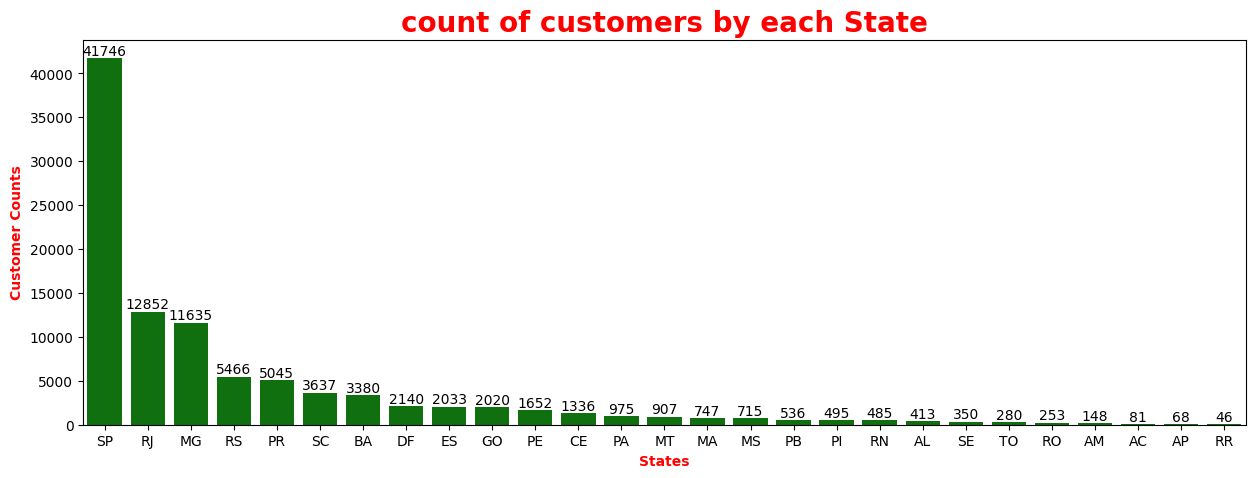

In [8]:
query = """ select customer_state states, count(customer_id) customers from customers
group by customer_state"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['States','Customer_Counts'])
df=df.sort_values(by = "Customer_Counts", ascending = False)

plt.figure(figsize=(15,5))
ax = sns.barplot(x=df['States'],y=df['Customer_Counts'],color='green', data=df)
plt.xticks(rotation = 0)
ax.bar_label(ax.containers[0])
plt.title('count of customers by each State',size=20, color='red', fontweight = 'bold')
plt.xlabel("States",color='red', fontweight='bold')
plt.ylabel("Customer Counts",color='red', fontweight='bold')
plt.show()

# 6. Count the number of customers from each Category. 

In [7]:
query = """ select Upper(products.product_category) category , count(orders.customer_id) Customers
from products join order_items on products.product_id = order_items.product_id join orders 
on order_items.order_id = orders.order_id group by category"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category','Customer_Counts'])
df.head()

,Category,Customer_Counts
0,HOUSEWARES,6964
1,BABIES,3065
2,COOL STUFF,3796
3,HEALTH BEAUTY,9670
4,FURNITURE KITCHEN SERVICE AREA DINNER AND GARDEN,281


# 7. Calculate the number of orders per month in 2018.

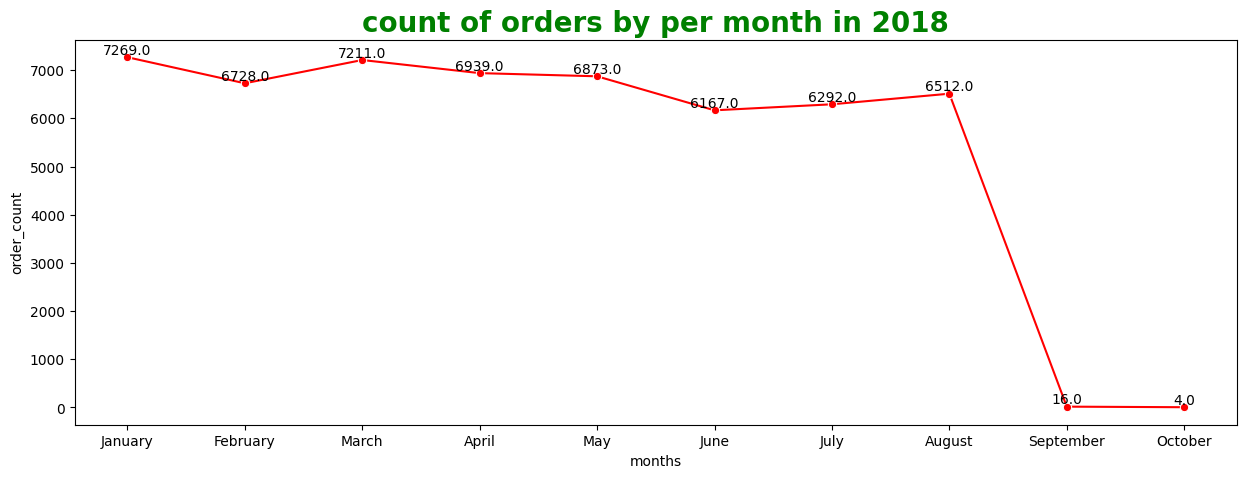

In [8]:
query = """ select monthname(order_purchase_timestamp) month, count(order_id) order_count
from orders where year(order_purchase_timestamp) = 2018 group by month"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['months','order_count'])

df['months'] = pd.Categorical(df['months'], categories=["January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October"], ordered=True)

plt.figure(figsize=(15,5))
ax=sns.lineplot(x=df['months'],y=df['order_count'],color='red',marker = 'o', data = df)
plt.title('count of orders by per month in 2018',size=20, color='green', fontweight = 'bold')

for i in range(df.shape[0]):
    ax.text(
        df['months'][i],
        df['order_count'][i],
        f"{df['order_count'][i]:.1f}",
        va='bottom',
        ha='center'
    )
plt.show()

# 7. Find the average number of products per order, grouped by customer city.

In [9]:
query = """ with count_per_order as 
( select orders.order_id, orders.customer_id, count(order_items.order_id) as order_count
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id )

select customers.customer_city , round(avg(count_per_order.order_count),2) average_order
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_order desc
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['customer_city','average_products/order'])
df=df.head(10)

,customer_city,average_products/order
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00
5,cidelandia,4.00
6,picarra,4.00
7,morro de sao paulo,4.00
8,teixeira soares,4.00
9,curralinho,4.00


# 8. Calculate the percentage of total revenue contributed by each product category.

In [10]:
query = """ Select Upper(products.product_category) Category, 
round((sum(payments.payment_value)/(select sum(payment_value) from payments)*100),2) Sales_percentage
from products join order_items 
on products.product_id = order_items.product_id 
join payments 
on payments.order_id = order_items.order_id
group by Category  order by sales_percentage desc"""

cur.execute(query) 

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category','percentage distribution'])

df.head()


,Category,percentage distribution
0,BED TABLE BATH,10.70
1,HEALTH BEAUTY,10.35
2,COMPUTER ACCESSORIES,9.90
3,FURNITURE DECORATION,8.93
4,WATCHES PRESENT,8.93


# 9. Identify the correlation between product price and the number of times a product has been purchased.

In [11]:
query = """ select products.product_category category, count(order_items.product_id), round(avg(order_items.price),2)
from products join order_items on products.product_id = order_items.product_id
group by category  """

cur.execute(query) 

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category','order_count','price'])

# using pandas
#c=df.select_dtypes(['int','float'])
#c.corr()

# using numpy
arr1 = df["order_count"]
arr2 = df["price"]

a = np.corrcoef([arr1,arr2])
print("the correlation is", a[0][-1])

the correlation is -0.10631514167157562


# 10. Calculate the total revenue generated by each seller, and rank them by revenue.

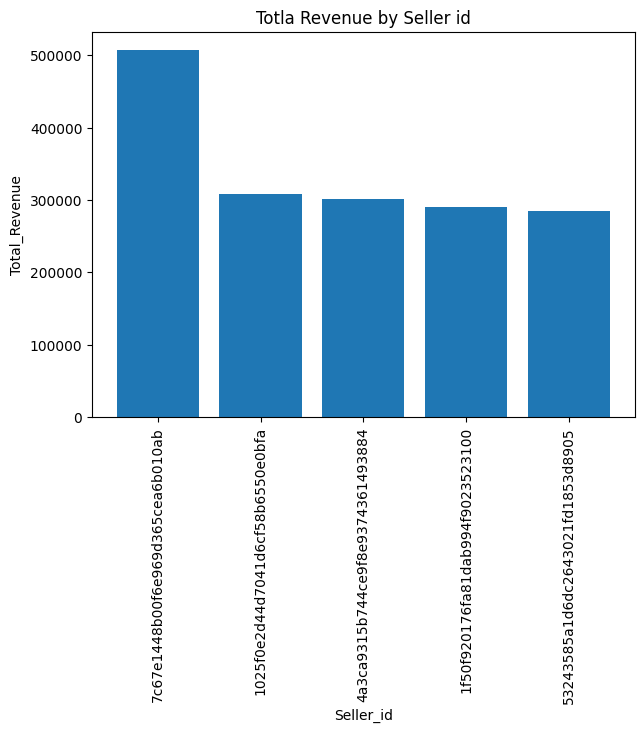

In [12]:
query = """with Revenue_Table AS (select order_items.seller_id Seller_id, sum(payments.payment_value) Total_Revenue
from order_items join payments 
on order_items.order_id=payments.order_id 
group by order_items.seller_id)
select Seller_id,Total_Revenue, dense_rank() over(order by Total_Revenue DESC) as Ranks from Revenue_Table """

cur.execute(query) 

data = cur.fetchall()

df = pd.DataFrame(data, columns=['seller_id','Total_Revenue','Rank'])
df=df.head()

plt.figure(figsize=(7,5))
plt.bar(df['seller_id'],df['Total_Revenue'])
plt.xticks(rotation=90)
plt.title("Totla Revenue by Seller id")
plt.xlabel("Seller_id")
plt.ylabel("Total_Revenue")
plt.show()

# 11. Calculate the moving average of order values for each customer over their order history.

In [13]:
query = """select customer_id, order_purchase_timestamp, payment,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id, orders.order_purchase_timestamp, 
payments.payment_value as payment
from payments join orders
on payments.order_id = orders.order_id) as a """

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['customer_id','Order_purchase','Payment','Mov_Avg'])
df


,customer_id,Order_purchase,Payment,Mov_Avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


# 12. Calculate the cumulative sales per month for each year.

In [14]:
query = """select years,months,payment, round(sum(payment) over(order by years,months),2) as comulative_Sales
from (Select year(orders.order_purchase_timestamp) as years, month(orders.order_purchase_timestamp) as months, round(sum(payments.payment_value),2) as payment
from orders join payments 
on orders.order_id = payments.order_id 
group by years, months order by years,months) as tabel1;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['Years','Months','Payment','Comulative_Sales'])
df

,Years,Months,Payment,Comulative_Sales
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


# 13. Calculate the year-over-year growth rate of total sales.

In [18]:
query = """
WITH a AS (
    SELECT 
        YEAR(orders.order_purchase_timestamp) AS years, 
        ROUND(SUM(payments.payment_value), 2) AS payment 
    FROM orders 
    JOIN payments ON orders.order_id = payments.order_id 
    GROUP BY YEAR(orders.order_purchase_timestamp)
) 
SELECT 
    years, 
    ((payment - LAG(payment, 1) OVER (ORDER BY years)) / LAG(payment, 1) OVER (ORDER BY years)) * 100 
FROM a;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['Years','YOY_%_Growth'])
df

,Years,YOY_%_Growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# 14. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [19]:
query = """with a as (select customers.customer_id,
min(orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as (select a.customer_id, count(distinct orders.order_purchase_timestamp) next_order
from a join orders
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < 
date_add(first_order, interval 6 month)
group by a.customer_id) 

select 100 * (count( distinct a.customer_id)/ count(distinct b.customer_id)) 
from a left join b 
on a.customer_id = b.customer_id ;"""

cur.execute(query)
data = cur.fetchall()

data

[(None,)]

# 15.Identify the top 3 customers who spent the most money in each year.

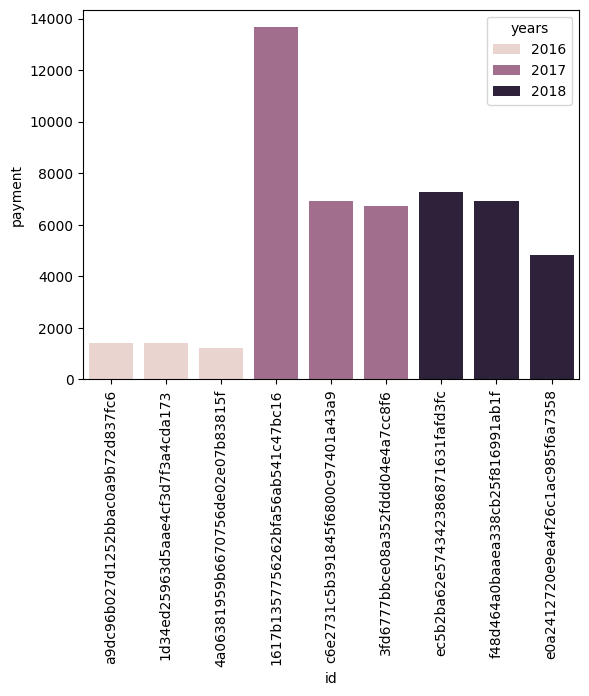

In [20]:
query = """select years, customer_id, payment, d_rank
from
(select year(orders.order_purchase_timestamp) years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) d_rank
from orders join payments 
on payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank <= 3 ;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years","id","payment","rank"])
sns.barplot(x = "id", y = "payment", data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()